# Machine Learning Models Comparison
## Neural Network, SVM, and Decision Tree Implementation


** Usar PyTorch :**
```bash
pip install torch torchvision
```

```bash
pip install scikit-learn pandas matplotlib seaborn numpy
```
```bash
pip install tensorflow-cpu==2.20.0
```

In [2]:
#import sys
#!{sys.executable} -m pip install tensorflow




In [3]:
#import sys
#!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn


In [4]:
import tensorflow as tf
import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split

## 1. Data Loading and Preprocessing

In [5]:

data = pd.read_csv('DOMensalEstadoDesde1991.csv', sep=';')




In [6]:
data

,ano,mes,hom_doloso,lesao_corp_morte,latrocinio,cvli,hom_por_interv_policial,letalidade_violenta,tentat_hom,lesao_corp_dolosa,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,1991,1,657,NaN,15,NaN,NaN,672,162,3051,...,NaN,NaN,NaN,NaN,217,NaN,NaN,NaN,NaN,3
1,1991,2,732,NaN,17,NaN,NaN,749,175,3421,...,NaN,NaN,NaN,NaN,209,NaN,NaN,NaN,NaN,3
2,1991,3,713,NaN,25,NaN,NaN,738,216,3613,...,NaN,NaN,NaN,NaN,188,NaN,NaN,NaN,NaN,3
3,1991,4,634,NaN,20,NaN,NaN,654,200,3211,...,NaN,NaN,NaN,NaN,140,NaN,NaN,NaN,NaN,3
4,1991,5,650,NaN,20,NaN,NaN,670,146,3051,...,NaN,NaN,NaN,NaN,78,NaN,NaN,NaN,NaN,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
411,2025,4,211,6.0,9,226.0,83.0,309,292,4986,...,933.0,105.0,5498.0,498.0,31,1.0,0.0,0.0,75761.0,3
412,2025,5,257,5.0,4,266.0,44.0,310,278,4962,...,1022.0,115.0,5559.0,496.0,37,5.0,1.0,1.0,80423.0,3
413,2025,6,219,5.0,1,225.0,45.0,270,294,4938,...,909.0,112.0,5279.0,492.0,38,0.0,0.0,0.0,77260.0,3
414,2025,7,178,4.0,8,190.0,47.0,237,269,4755,...,1003.0,116.0,5413.0,486.0,36,7.0,2.0,0.0,83127.0,2


In [7]:
# Verificar valores ausentes
missing_values = data.isnull().sum()
missing_summary = missing_values[missing_values > 0]

print("Valores ausentes por coluna:")
print(missing_summary)

Valores ausentes por coluna:
lesao_corp_morte               96
cvli                           96
hom_por_interv_policial        84
estupro                       144
hom_culposo                    84
lesao_corp_culposa             96
roubo_celular                 108
roubo_cx_eletronico           144
roubo_conducao_saque          144
roubo_apos_saque              144
roubo_bicicleta               276
furto_coletivo                144
furto_celular                 144
furto_bicicleta               276
sequestro                      96
extorsao                      144
sequestro_relampago           144
estelionato                   144
posse_drogas                  180
trafico_drogas                180
apreensao_drogas_sem_autor    180
apf                           180
aaapai                        180
cmp                           180
cmba                          180
ameaca                         96
pessoas_desaparecidas         132
encontro_ossada               132
pol_militares_morto

In [8]:
# Informações gerais
print(f"\nInformações do dataset:")
print(f"- Registros: {len(data):,}")
print(f"- Colunas: {len(data.columns)}")
print(f"- Tipos de dados:")
print(data.dtypes.value_counts())

# Mostrar algumas estatísticas
data.describe()


Informações do dataset:
- Registros: 416
- Colunas: 56
- Tipos de dados:
float64    31
int64      25
Name: count, dtype: int64


,ano,mes,hom_doloso,lesao_corp_morte,latrocinio,cvli,hom_por_interv_policial,letalidade_violenta,tentat_hom,lesao_corp_dolosa,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
count,416.000000,416.000000,416.000000,320.000000,416.000000,320.000000,332.000000,416.000000,416.000000,416.000000,...,236.000000,236.000000,320.000000,284.000000,416.000000,284.000000,272.000000,272.000000,320.000000,416.000000
mean,2007.836538,6.461538,463.668269,4.250000,14.165865,434.121875,76.003012,541.759615,318.939904,5387.713942,...,1188.970339,86.199153,5381.612500,431.468310,59.901442,3.161972,1.808824,0.294118,56085.778125,2.995192
std,10.020808,3.448549,137.761399,2.681645,6.400594,116.850308,37.777653,126.842944,118.101830,1430.189787,...,344.803384,62.239880,1093.088521,75.548237,34.835343,2.191011,1.668084,0.596641,12047.997305,0.069254
min,1991.000000,1.000000,178.000000,0.000000,1.000000,190.000000,10.000000,237.000000,122.000000,2350.000000,...,544.000000,2.000000,1409.000000,178.000000,0.000000,0.000000,0.000000,0.000000,30621.000000,2.000000
25%,1999.000000,3.000000,350.000000,2.000000,10.000000,337.750000,45.000000,444.750000,212.000000,4401.000000,...,908.250000,46.000000,4744.000000,385.750000,35.000000,2.000000,1.000000,0.000000,47675.000000,3.000000
50%,2008.000000,6.000000,471.000000,4.000000,13.000000,438.500000,74.000000,557.000000,320.500000,5589.000000,...,1120.500000,61.000000,5368.000000,427.000000,50.000000,3.000000,1.000000,0.000000,56359.000000,3.000000
75%,2016.250000,9.000000,557.250000,6.000000,18.000000,532.250000,101.000000,638.000000,386.250000,6443.750000,...,1443.500000,109.000000,6048.000000,486.250000,80.000000,4.000000,3.000000,0.000000,65278.250000,3.000000
max,2025.000000,12.000000,831.000000,21.000000,36.000000,710.000000,195.000000,848.000000,645.000000,9050.000000,...,2314.000000,350.000000,9034.000000,628.000000,217.000000,13.000000,10.000000,3.000000,84129.000000,3.000000


In [9]:
# Fazer uma cópia para processamento
df_processed = data.copy()


In [10]:
# Substituir valores NaN por 0 (assumindo que são crimes não ocorridos)
numeric_columns = df_processed.select_dtypes(include=[np.number]).columns
df_processed[numeric_columns] = df_processed[numeric_columns].fillna(0)

In [11]:
# Converter colunas que devem ser numéricas
for col in df_processed.columns:
    if col not in ['data', 'fase']:  # Excluir colunas de data/texto
        try:
            df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
            df_processed[col] = df_processed[col].fillna(0)
        except:
            pass


## FEATURES

In [12]:
# Taxa de criminalidade geral
crime_columns = [col for col in df_processed.columns if any(x in col.lower() 
                for x in ['hom', 'roubo', 'furto', 'lesao', 'estupro', 'latrocinio'])]

if crime_columns:
    df_processed['total_crimes'] = df_processed[crime_columns].sum(axis=1)
    
    # Proporções de diferentes tipos de crime
    violent_crimes = [col for col in crime_columns if any(x in col.lower() 
                     for x in ['hom', 'lesao_corp_morte', 'latrocinio', 'estupro', 'tentat_hom'])]
    property_crimes = [col for col in crime_columns if any(x in col.lower() 
                      for x in ['roubo', 'furto'])]
    
    if violent_crimes:
        df_processed['total_crimes_violentos'] = df_processed[violent_crimes].sum(axis=1)
        df_processed['prop_crimes_violentos'] = (df_processed['total_crimes_violentos'] / 
                                               (df_processed['total_crimes'] + 1))
    
    if property_crimes:
        df_processed['total_crimes_patrimonio'] = df_processed[property_crimes].sum(axis=1)
        df_processed['prop_crimes_patrimonio'] = (df_processed['total_crimes_patrimonio'] / 
                                                (df_processed['total_crimes'] + 1))

In [13]:
# Taxa de recuperação de veículos
if 'recuperacao_veiculos' in df_processed.columns and 'roubo_veiculo' in df_processed.columns:
    df_processed['taxa_recuperacao_veiculos'] = (df_processed['recuperacao_veiculos'] / 
                                               (df_processed['roubo_veiculo'] + df_processed['furto_veiculos'] + 1))

# Eficiência em apreensão de drogas
drug_columns = [col for col in df_processed.columns if 'droga' in col.lower()]
if drug_columns:
    df_processed['total_operacoes_drogas'] = df_processed[drug_columns].sum(axis=1)

# Taxa de mortalidade policial
police_death_cols = [col for col in df_processed.columns if 'policial' in col.lower() and 'mort' in col.lower()]
if police_death_cols:
    df_processed['total_policiais_mortos'] = df_processed[police_death_cols].sum(axis=1)

In [14]:

# Crimes organizados (que requerem planejamento)
organized_crimes = ['latrocinio', 'sequestro', 'roubo_banco', 'roubo_carga', 'trafico_drogas']
organized_crimes = [col for col in organized_crimes if col in df_processed.columns]

if organized_crimes:
    df_processed['crimes_organizados'] = df_processed[organized_crimes].sum(axis=1)
    df_processed['prop_crimes_organizados'] = (df_processed['crimes_organizados'] / 
                                             (df_processed['total_crimes'] + 1))

# Crimes oportunistas
opportunistic_crimes = ['roubo_transeunte', 'roubo_celular', 'furto_transeunte', 'furto_celular']
opportunistic_crimes = [col for col in opportunistic_crimes if col in df_processed.columns]

if opportunistic_crimes:
    df_processed['crimes_oportunistas'] = df_processed[opportunistic_crimes].sum(axis=1)

In [15]:
#FEATURES DE TENDÊNCIA E VOLATILIDADE


# Ordenar por ano e mês para calcular tendências
if 'ano' in df_processed.columns and 'mes' in df_processed.columns:
    df_processed = df_processed.sort_values(['ano', 'mes'])
    
    # Moving averages para detectar tendências
    window = 3  # 3 meses
    for col in ['total_crimes', 'total_crimes_violentos']:
        if col in df_processed.columns:
            df_processed[f'{col}_ma3'] = df_processed[col].rolling(window=window, min_periods=1).mean()
            df_processed[f'{col}_tendencia'] = df_processed[col] - df_processed[f'{col}_ma3']
            
    # Volatilidade (desvio padrão móvel)
    for col in ['total_crimes', 'hom_doloso']:
        if col in df_processed.columns:
            df_processed[f'{col}_volatilidade'] = df_processed[col].rolling(window=6, min_periods=1).std().fillna(0)

In [16]:

if 'total_crimes' in df_processed.columns:
    df_processed['nivel_criminalidade'] = pd.cut(df_processed['total_crimes'], 
                                                bins=5, labels=['Muito Baixo', 'Baixo', 'Médio', 'Alto', 'Muito Alto'])
    df_processed['criminalidade_extrema'] = (df_processed['total_crimes'] > 
                                           df_processed['total_crimes'].quantile(0.9)).astype(int)

# Categorizar homicídios
if 'hom_doloso' in df_processed.columns:
    df_processed['alto_homicidio'] = (df_processed['hom_doloso'] > 
                                    df_processed['hom_doloso'].quantile(0.75)).astype(int)

In [17]:
# FEATURES ESPECÍFICAS POR TIPO DE LOCAL


# Crimes em estabelecimentos vs. via pública
establishment_crimes = ['roubo_comercio', 'roubo_banco', 'roubo_residencia']
establishment_crimes = [col for col in establishment_crimes if col in df_processed.columns]

street_crimes = ['roubo_transeunte', 'roubo_celular', 'roubo_rua']
street_crimes = [col for col in street_crimes if col in df_processed.columns]

if establishment_crimes:
    df_processed['crimes_estabelecimentos'] = df_processed[establishment_crimes].sum(axis=1)

if street_crimes:
    df_processed['crimes_via_publica'] = df_processed[street_crimes].sum(axis=1)

if establishment_crimes and street_crimes:
    df_processed['razao_estabelecimento_rua'] = (df_processed['crimes_estabelecimentos'] / 
                                               (df_processed['crimes_via_publica'] + 1))

In [18]:
# FEATURES DE RISCO E SEGURANÇA


# Índice de risco geral
risk_factors = ['hom_doloso', 'latrocinio', 'sequestro', 'estupro']
risk_factors = [col for col in risk_factors if col in df_processed.columns]

if risk_factors:
    df_processed['indice_risco'] = df_processed[risk_factors].sum(axis=1)
    df_processed['risco_normalizado'] = (df_processed['indice_risco'] - df_processed['indice_risco'].min()) / \
                                      (df_processed['indice_risco'].max() - df_processed['indice_risco'].min() + 1)

# Segurança patrimonial
if 'recuperacao_veiculos' in df_processed.columns and 'total_crimes_patrimonio' in df_processed.columns:
    df_processed['efetividade_recuperacao'] = (df_processed['recuperacao_veiculos'] / 
                                             (df_processed['total_crimes_patrimonio'] + 1))



## 2. Neural Network Implementation
Implementação com múltiplos backends (TensorFlow, PyTorch, ou Scikit-learn)

In [20]:
# Célula corrigida: Preparação dos dados para Machine Learning
from sklearn.feature_selection import SelectKBest, f_classif

median_crimes = df_processed['total_crimes'].median()
df_processed['target_criminalidade'] = (df_processed['total_crimes'] > median_crimes).astype(int)
target_column = 'target_criminalidade'

print(f"Target criado: {target_column}")
print(f"Mediana de crimes: {median_crimes}")
print(f"Distribuição do target: {df_processed[target_column].value_counts()}")

# Separar features e target
y = df_processed[target_column]

# Verificar quais colunas existem antes de removê-las
columns_to_remove = [target_column]  # Sempre remover o target
optional_columns = ['data', 'fase', 'nivel_criminalidade']

# Adicionar apenas colunas que existem
for col in optional_columns:
    if col in df_processed.columns:
        columns_to_remove.append(col)
        print(f"Removendo coluna: {col}")

print(f"Colunas a serem removidas: {columns_to_remove}")

# Criar X removendo as colunas identificadas
X = df_processed.drop(columns=columns_to_remove)

print(f"Shape inicial de X: {X.shape}")

# Manter apenas colunas numéricas
numeric_columns = X.select_dtypes(include=[np.number]).columns
X_numeric = X[numeric_columns]

print(f"Colunas numéricas mantidas: {len(numeric_columns)}")
print(f"Shape após filtro numérico: {X_numeric.shape}")

# Verificar e limpar dados problemáticos
print("Verificando dados problemáticos...")
print(f"Valores infinitos: {np.isinf(X_numeric).sum().sum()}")
print(f"Valores NaN: {X_numeric.isna().sum().sum()}")

# Limpar valores infinitos e NaN
X_clean = X_numeric.replace([np.inf, -np.inf], np.nan)
X_clean = X_clean.fillna(0)

print(f"Shape final: {X_clean.shape}")

# Seleção das melhores features
k_features = min(20, X_clean.shape[1])
print(f"Selecionando {k_features} melhores features...")

selector = SelectKBest(score_func=f_classif, k=k_features)
X_selected = selector.fit_transform(X_clean, y)

# Obter nomes das features selecionadas
selected_features_mask = selector.get_support()
feature_names = X_clean.columns[selected_features_mask].tolist()

print(f"✅ Features selecionadas: {len(feature_names)}")
print("Top 10 features:")
feature_scores = selector.scores_[selected_features_mask]
for i, (name, score) in enumerate(zip(feature_names[:10], feature_scores[:10])):
    print(f"  {i+1:2d}. {name}: {score:.2f}")

# Salvar variáveis para uso posterior
X = X_clean

Target criado: target_criminalidade
Mediana de crimes: 56696.0
Distribuição do target: target_criminalidade
0    208
1    208
Name: count, dtype: int64
Removendo coluna: fase
Removendo coluna: nivel_criminalidade
Colunas a serem removidas: ['target_criminalidade', 'fase', 'nivel_criminalidade']
Shape inicial de X: (416, 79)
Colunas numéricas mantidas: 79
Shape após filtro numérico: (416, 79)
Verificando dados problemáticos...
Valores infinitos: 0
Valores NaN: 0
Shape final: (416, 79)
Selecionando 20 melhores features...
✅ Features selecionadas: 20
Top 10 features:
   1. estupro: 565.92
   2. roubo_transeunte: 757.65
   3. roubo_rua: 613.47
   4. furto_transeunte: 588.36
   5. furto_coletivo: 1261.99
   6. furto_celular: 487.74
   7. outros_furtos: 647.28
   8. total_furtos: 1175.07
   9. apreensao_drogas_sem_autor: 714.80
  10. apf: 502.59


In [21]:
# Célula: Divisão treino/teste e normalização
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# Normalização dos dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Dados preparados para treinamento:")
print(f"   Training set: {X_train_scaled.shape}")
print(f"   Test set: {X_test_scaled.shape}")
print(f"   Features: {len(feature_names)}")
print(f"   Classes: {len(np.unique(y))}")

# Verificar balanceamento das classes
print(f"\nDistribuição das classes:")
print(f"Treino: Classe 0: {(y_train==0).sum()} | Classe 1: {(y_train==1).sum()}")
print(f"Teste:  Classe 0: {(y_test==0).sum()} | Classe 1: {(y_test==1).sum()}")

# Definir nomes das classes para relatórios
target_names = ['Baixa Criminalidade', 'Alta Criminalidade']

# Definir backend da rede neural
NEURAL_NETWORK_BACKEND = "tensorflow"
MATPLOTLIB_AVAILABLE = True
SEABORN_AVAILABLE = True

print(f"Backend Neural Network: {NEURAL_NETWORK_BACKEND}")

✅ Dados preparados para treinamento:
   Training set: (332, 20)
   Test set: (84, 20)
   Features: 20
   Classes: 2

Distribuição das classes:
Treino: Classe 0: 166 | Classe 1: 166
Teste:  Classe 0: 42 | Classe 1: 42
Backend Neural Network: tensorflow


In [22]:
# Célula: Implementação da Rede Neural com Keras/TensorFlow
def create_neural_network_keras(input_dim):
    """
    Criar rede neural otimizada para classificação de criminalidade
    """
    model = tf.keras.Sequential([
        # Camada de entrada
        tf.keras.layers.Dense(128, input_dim=input_dim, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        
        # Camadas ocultas
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        
        # Camada de saída (classificação binária)
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    
    # Compilar o modelo
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

print("🧠 Criando e treinando Rede Neural...")

# Criar o modelo
nn_model = create_neural_network_keras(X_train_scaled.shape[1])

# Mostrar arquitetura
print("\n📋 Arquitetura da Rede Neural:")
nn_model.summary()

# Callbacks para otimizar treinamento
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=0.0001,
        verbose=1
    )
]

# Treinar o modelo
print("\n🚀 Iniciando treinamento...")
history = nn_model.fit(
    X_train_scaled, y_train,
    batch_size=32,
    epochs=100,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Rede Neural treinada com sucesso!")

# Avaliar no conjunto de teste
test_loss, test_accuracy = nn_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"📊 Performance no teste: Loss = {test_loss:.4f}, Accuracy = {test_accuracy:.4f}")

🧠 Criando e treinando Rede Neural...


c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



📋 Arquitetura da Rede Neural:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,337 (56.00 KB)

 Trainable params: 13,953 (54.50 KB)

 Non-trainable params: 384 (1.50 KB)


🚀 Iniciando treinamento...
Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.6264 - loss: 0.6501 - val_accuracy: 0.9104 - val_loss: 0.6021 - learning_rate: 0.0010
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8642 - loss: 0.3745 - val_accuracy: 0.9254 - val_loss: 0.5109 - learning_rate: 0.0010
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9019 - loss: 0.3023 - val_accuracy: 0.9254 - val_loss: 0.4311 - learning_rate: 0.0010
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9321 - loss: 0.2485 - val_accuracy: 0.9254 - val_loss: 0.3649 - learning_rate: 0.0010
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9170 - loss: 0.2363 - val_accuracy: 0.9254 - val_loss: 0.3151 - learning_rate: 0.0010
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9736 - loss: 0.1471 - val_accuracy: 0.9254 - val_loss: 0.2769 - learning_rate: 0.0010
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9585 - l

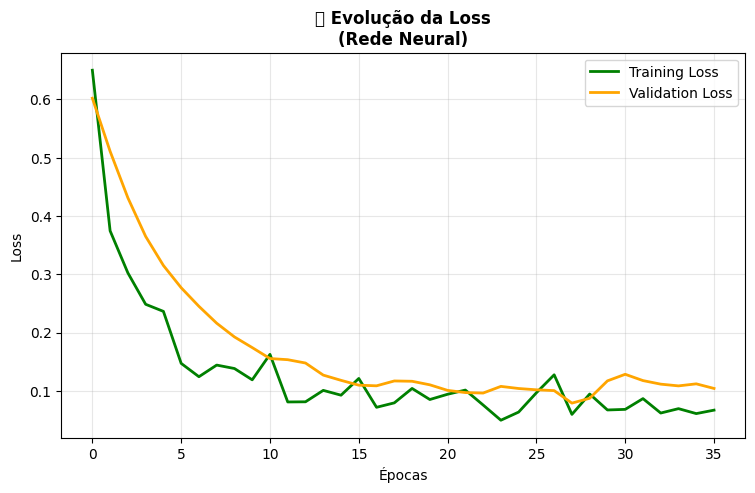

In [27]:
plt.figure(figsize=(30, 5))
#  Loss durante o treinamento
plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Training Loss', color='green', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('📉 Evolução da Loss\n(Rede Neural)', fontsize=12, fontweight='bold')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)



In [29]:
# Cálculo de Ein e Eout da Rede Neural
from sklearn.metrics import accuracy_score, log_loss

# Predições no conjunto de treinamento (Ein)
nn_train_pred_proba = nn_model.predict(X_train_scaled)
nn_train_pred = (nn_train_pred_proba > 0.5).astype(int).flatten()

# Predições no conjunto de teste (Eout)
nn_test_pred_proba = nn_model.predict(X_test_scaled)
nn_test_pred = (nn_test_pred_proba > 0.5).astype(int).flatten()

# Calcular Ein (Training Error)
ein_accuracy = accuracy_score(y_train, nn_train_pred)
ein_loss = log_loss(y_train, nn_train_pred_proba)
ein_error = 1 - ein_accuracy

# Calcular Eout (Test Error)  
eout_accuracy = accuracy_score(y_test, nn_test_pred)
eout_loss = log_loss(y_test, nn_test_pred_proba)
eout_error = 1 - eout_accuracy

print("📊 ANÁLISE Ein vs Eout - REDE NEURAL")
print("="*50)
print(f"Ein (Training Error):")
print(f"  • Accuracy: {ein_accuracy:.4f}")
print(f"  • Error Rate: {ein_error:.4f}")
print(f"  • Loss: {ein_loss:.4f}")
print(f"\nEout (Test Error):")
print(f"  • Accuracy: {eout_accuracy:.4f}")
print(f"  • Error Rate: {eout_error:.4f}")
print(f"  • Loss: {eout_loss:.4f}")
print(f"\nDiferença (Eout - Ein):")
print(f"  • Error Difference: {eout_error - ein_error:.4f}")
print(f"  • Loss Difference: {eout_loss - ein_loss:.4f}")


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
📊 ANÁLISE Ein vs Eout - REDE NEURAL
Ein (Training Error):
  • Accuracy: 0.9789
  • Error Rate: 0.0211
  • Loss: 0.0714

Eout (Test Error):
  • Accuracy: 0.9524
  • Error Rate: 0.0476
  • Loss: 0.1316

Diferença (Eout - Ein):
  • Error Difference: 0.0265
  • Loss Difference: 0.0603


## 3. Support Vector Machine Implementation

In [ ]:
# SVM Model with hyperparameter tuning
svm_params = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.1, 1]
}

svm_model = SVC(random_state=42)
svm_grid = GridSearchCV(svm_model, svm_params, cv=5, scoring='accuracy', n_jobs=-1)

print("Training SVM with Grid Search...")
svm_grid.fit(X_train_scaled, y_train)

print(f"Best SVM parameters: {svm_grid.best_params_}")
print(f"Best SVM cross-validation score: {svm_grid.best_score_:.4f}")

# Get the best SVM model
best_svm = svm_grid.best_estimator_

NameError: name 'SVC' is not defined

## 4. Decision Tree Implementation

In [ ]:
# Decision Tree Model with hyperparameter tuning
dt_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt_model = DecisionTreeClassifier(random_state=42)
dt_grid = GridSearchCV(dt_model, dt_params, cv=5, scoring='accuracy', n_jobs=-1)

print("Training Decision Tree with Grid Search...")
dt_grid.fit(X_train_scaled, y_train)

print(f"Best Decision Tree parameters: {dt_grid.best_params_}")
print(f"Best Decision Tree cross-validation score: {dt_grid.best_score_:.4f}")

# Get the best Decision Tree model
best_dt = dt_grid.best_estimator_

## 5. Model Evaluation and Comparison

In [ ]:
# Make predictions adaptado para diferentes backends
if NEURAL_NETWORK_BACKEND == "tensorflow":
    nn_pred = np.argmax(nn_model.predict(X_test_scaled), axis=1)
elif NEURAL_NETWORK_BACKEND == "pytorch":
    with torch.no_grad():
        outputs = nn_model(X_test_tensor)
        nn_pred = torch.argmax(outputs, axis=1).numpy()
else:  # sklearn
    nn_pred = nn_model.predict(X_test_scaled)

svm_pred = best_svm.predict(X_test_scaled)
dt_pred = best_dt.predict(X_test_scaled)

# Calculate accuracies
nn_accuracy = accuracy_score(y_test, nn_pred)
svm_accuracy = accuracy_score(y_test, svm_pred)
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Model Accuracies:")
print(f"Neural Network ({NEURAL_NETWORK_BACKEND}): {nn_accuracy:.4f}")
print(f"SVM: {svm_accuracy:.4f}")
print(f"Decision Tree: {dt_accuracy:.4f}")

In [ ]:
# Detailed classification reports
models = ['Neural Network', 'SVM', 'Decision Tree']
predictions = [nn_pred, svm_pred, dt_pred]

for model_name, pred in zip(models, predictions):
    print(f"\n{'='*50}")
    print(f"Classification Report - {model_name}")
    print(f"{'='*50}")
    print(classification_report(y_test, pred, target_names=target_names))

In [ ]:
# Confusion matrices visualization adaptado
if MATPLOTLIB_AVAILABLE and SEABORN_AVAILABLE:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    models = [f'Neural Network ({NEURAL_NETWORK_BACKEND})', 'SVM', 'Decision Tree']
    predictions = [nn_pred, svm_pred, dt_pred]

    for i, (model_name, pred) in enumerate(zip(models, predictions)):
        cm = confusion_matrix(y_test, pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
        axes[i].set_title(f'{model_name}\nAccuracy: {accuracy_score(y_test, pred):.4f}')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')

    plt.tight_layout()
    plt.show()
else:
    print("📊 Visualização não disponível. Resultados das matrizes de confusão:")
    models = [f'Neural Network ({NEURAL_NETWORK_BACKEND})', 'SVM', 'Decision Tree']
    predictions = [nn_pred, svm_pred, dt_pred]
    
    for model_name, pred in zip(models, predictions):
        cm = confusion_matrix(y_test, pred)
        print(f"\n{model_name}:")
        print(cm)

In [ ]:
# Model comparison chart adaptado
models = [f'Neural Network\n({NEURAL_NETWORK_BACKEND})', 'SVM', 'Decision Tree']
accuracies = [nn_accuracy, svm_accuracy, dt_accuracy]

if MATPLOTLIB_AVAILABLE:
    colors = ['skyblue', 'lightgreen', 'lightcoral']
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(models, accuracies, color=colors)
    plt.title('Model Accuracy Comparison')
    plt.xlabel('Models')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1)

    # Add accuracy values on top of bars
    for bar, acc in zip(bars, accuracies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                 f'{acc:.4f}', ha='center', va='bottom')

    plt.grid(axis='y', alpha=0.3)
    plt.show()
else:
    print("📊 Comparação de Modelos (modo texto):")
    for model, acc in zip(models, accuracies):
        print(f"{model}: {acc:.4f}")

## 6. Cross-Validation Analysis

In [ ]:
# Cross-validation adaptado para diferentes backends
from sklearn.model_selection import KFold

def nn_cross_val_sklearn(X, y, cv=5):
    """Cross-validation para MLPClassifier"""
    model = MLPClassifier(hidden_layer_sizes=(64, 32, 16), max_iter=500, random_state=42)
    return cross_val_score(model, X, y, cv=cv)

def nn_cross_val_tensorflow(X, y, cv=5):
    """Cross-validation para TensorFlow"""
    scores = []
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    
    for train_idx, val_idx in kf.split(X):
        X_train_cv, X_val_cv = X[train_idx], X[val_idx]
        y_train_cv, y_val_cv = y[train_idx], y[val_idx]
        
        model = create_neural_network_tensorflow(X_train_cv.shape[1], len(np.unique(y)))
        model.fit(X_train_cv, y_train_cv, epochs=50, verbose=0)
        
        pred = np.argmax(model.predict(X_val_cv), axis=1)
        scores.append(accuracy_score(y_val_cv, pred))
    
    return np.array(scores)

# Perform cross-validation
print("Performing cross-validation...")

if NEURAL_NETWORK_BACKEND == "tensorflow":
    nn_cv_scores = nn_cross_val_tensorflow(X_train_scaled, y_train)
else:
    nn_cv_scores = nn_cross_val_sklearn(X_train_scaled, y_train)

svm_cv_scores = cross_val_score(best_svm, X_train_scaled, y_train, cv=5)
dt_cv_scores = cross_val_score(best_dt, X_train_scaled, y_train, cv=5)

print(f"\nCross-validation results:")
print(f"Neural Network ({NEURAL_NETWORK_BACKEND}): {nn_cv_scores.mean():.4f} (+/- {nn_cv_scores.std() * 2:.4f})")
print(f"SVM: {svm_cv_scores.mean():.4f} (+/- {svm_cv_scores.std() * 2:.4f})")
print(f"Decision Tree: {dt_cv_scores.mean():.4f} (+/- {dt_cv_scores.std() * 2:.4f})")

## 7. Feature Importance Analysis

In [ ]:
# Feature importance for Decision Tree
feature_importance = best_dt.feature_importances_

plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_names)), feature_importance)
plt.yticks(range(len(feature_names)), feature_names)
plt.xlabel('Feature Importance')
plt.title('Decision Tree Feature Importance')
plt.grid(axis='x', alpha=0.3)
plt.show()

# Print feature importance values
print("Feature Importance (Decision Tree):")
for name, importance in zip(feature_names, feature_importance):
    print(f"{name}: {importance:.4f}")

## 8. Summary and Conclusions

In [ ]:
# Summary table adaptado
models = [f'Neural Network ({NEURAL_NETWORK_BACKEND})', 'SVM', 'Decision Tree']
results_df = pd.DataFrame({
    'Model': models,
    'Test Accuracy': [nn_accuracy, svm_accuracy, dt_accuracy],
    'CV Mean': [nn_cv_scores.mean(), svm_cv_scores.mean(), dt_cv_scores.mean()],
    'CV Std': [nn_cv_scores.std(), svm_cv_scores.std(), dt_cv_scores.std()]
})

print("\nModel Comparison Summary:")
print(results_df.round(4))

# Best model
best_model_idx = np.argmax(results_df['Test Accuracy'])
best_model_name = results_df.iloc[best_model_idx]['Model']

print(f"\nBest performing model: {best_model_name}")
print(f"Test Accuracy: {results_df.iloc[best_model_idx]['Test Accuracy']:.4f}")

print(f"\n🎯 Backend utilizado: {NEURAL_NETWORK_BACKEND}")
if NEURAL_NETWORK_BACKEND == "none":
    print("💡 Dica: Para melhor performance, instale TensorFlow ou PyTorch")
    print("   pip install tensorflow-cpu  # ou")
    print("   pip install torch")